## Call Option: Time Value Decay

**Under assumption that rates are constant near 0**

**Key insight**: As maturity T → 0, the option price converges to the payoff max(S - K, 0)

- **Blue**: Payoff at expiry
- **Red curves**: Option prices (darker = longer maturity)
- More time = more time value above the payoff

**If rates are flat, the PV of the option converges to the payoff at expiry.**

#### $\frac{1}{\sqrt{2\pi}}$ can be approximated by 0.3989

If rates are flat, the PV of the option converges to the payoff at expiry.


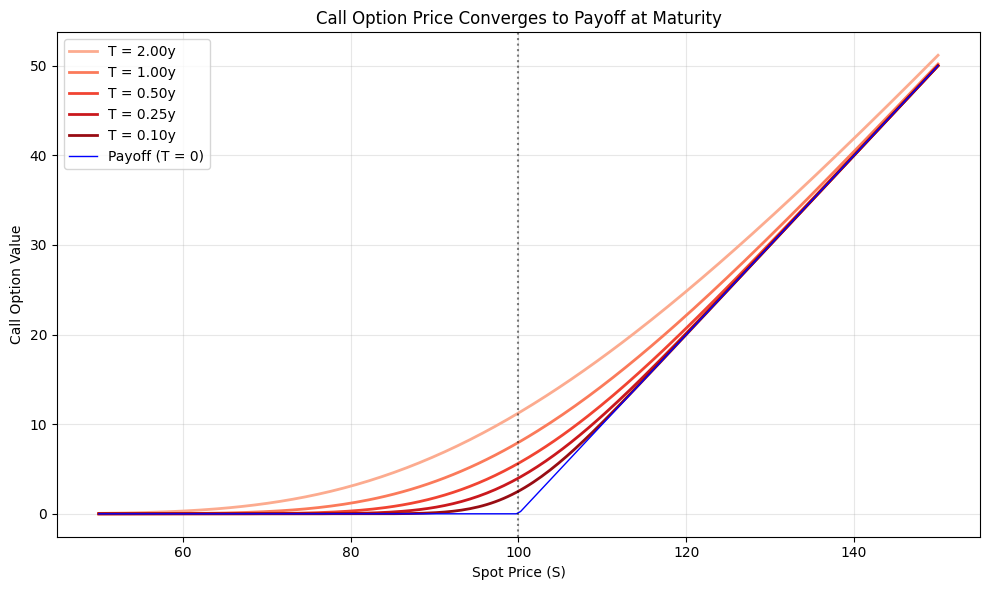

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def black_scholes_call(S, K, T, r, sigma):
    """Calculate the Black-Scholes price of a European call option."""
    if T <= 0:
        return max(S - K, 0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

# Parameters
K = 100          # Strike price
r = 0       # Risk-free rate
sigma = 0.2      # Volatility

# Maturities: from long to approaching expiry
maturities = [2.0, 1.0, 0.5, 0.25, 0.1]

# Spot prices range
S_range = np.linspace(50, 150, 200)

# Plotting
plt.figure(figsize=(10, 6))

# Plot option prices for each maturity (lighter = closer to expiry)
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(maturities)))

for T, color in zip(maturities, colors):
    call_prices = [black_scholes_call(S, K, T, r, sigma) for S in S_range]
    label = f'T = {T:.2f}y' if T >= 0.1 else f'T = {int(T*365)}d'
    plt.plot(S_range, call_prices, color=color, linewidth=2, label=label)

# PAYOFF at maturity (T = 0)
payoff = np.maximum(S_range - K, 0)
plt.plot(S_range, payoff, 'b', linewidth=1, label='Payoff (T = 0)')

plt.axvline(x=K, color='black', linestyle=':', alpha=0.5)
plt.xlabel('Spot Price (S)')
plt.ylabel('Call Option Value')
plt.title('Call Option Price Converges to Payoff at Maturity')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
print("If rates are flat, the PV of the option converges to the payoff at expiry.")
plt.show()


---

# Delta $\Delta$


$$\Delta_{\text{call}} = N(d_1) \quad \text{where} \quad d_1 = \frac{\ln(S/K) + \left(r + \frac{\sigma^2}{2}\right)T}{\sigma\sqrt{T}}$$

$$\Delta_{\text{put}} = N(d_1) - 1 = -N(-d_1)$$

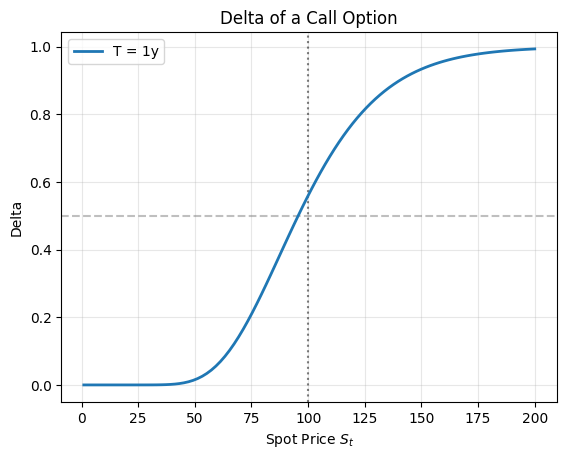

In [2]:
def delta_call(S, K, T, r, sigma):
    """
    Compute the delta of a call option using the Black-Scholes formula.
    """
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1)

S=np.linspace(1,200,100)
K=100
T=1
r=0
sigma=0.3

plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=K, color='black', linestyle=':', alpha=0.5)
plt.plot(S, delta_call(S, K, T, r, sigma), linewidth=2, label=f'T = {T}y')
plt.xlabel("Spot Price $S_t$")
plt.ylabel("Delta")
plt.title("Delta of a Call Option")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


**ATM:** $\Delta_c \approx 0.5$

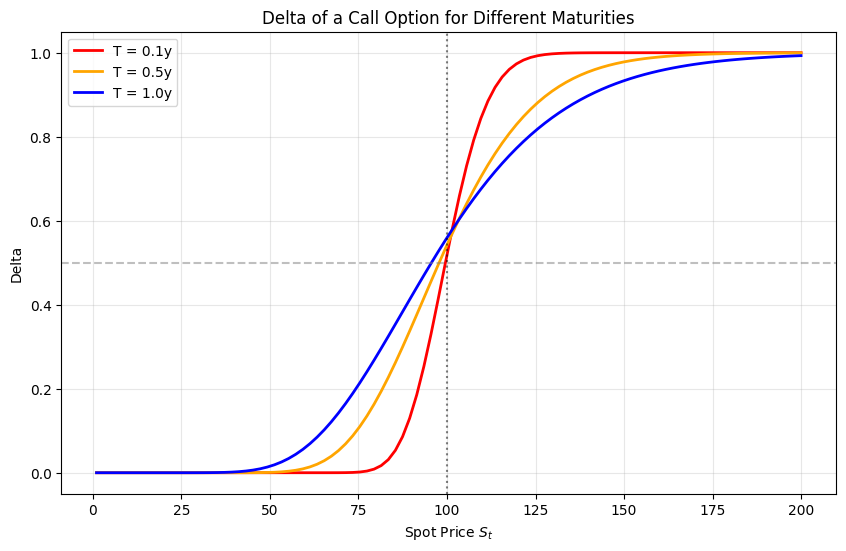

In [3]:
# Maturities
maturities = [0.1, 0.5, 1.0]  # t1 < t2 < t3
colors = ['red', 'orange', 'blue']

plt.figure(figsize=(10, 6))

for T, color in zip(maturities, colors):
    plt.plot(S, delta_call(S, K, T, r, sigma), color=color, linewidth=2, label=f'T = {T}y')

plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=K, color='black', linestyle=':', alpha=0.5)
plt.xlabel("Spot Price $S_t$")
plt.ylabel("Delta")
plt.title("Delta of a Call Option for Different Maturities")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

$$\text{For } T_1 < T_2: \quad \left| \frac{\partial \Delta}{\partial S} \right|_{T_1} > \left| \frac{\partial \Delta}{\partial S} \right|_{T_2}$$

$$T_1 < T_2 \implies \Delta_{T_1}(S) \text{ is steeper around } S = K$$


$$\lim_{T \to 0} \Delta_{\text{call}}(S) = \mathbf{1}_{S > K} = 
\begin{cases} 
1 & \text{if } S > K \\
0 & \text{if } S < K
\end{cases}$$


### Effect of T and σ on Delta

| Change | Effect on Delta curve |
|--------|----------------------|
| ↑ T or ↑ σ | Smoother, less steep transition around ATM |
| ↓ T or ↓ σ | Steeper, more step-like at $S = K$ |

As $T \to 0$ or $\sigma \to 0$:

$$\Delta_{\text{call}} \to \mathbf{1}_{S > K}$$

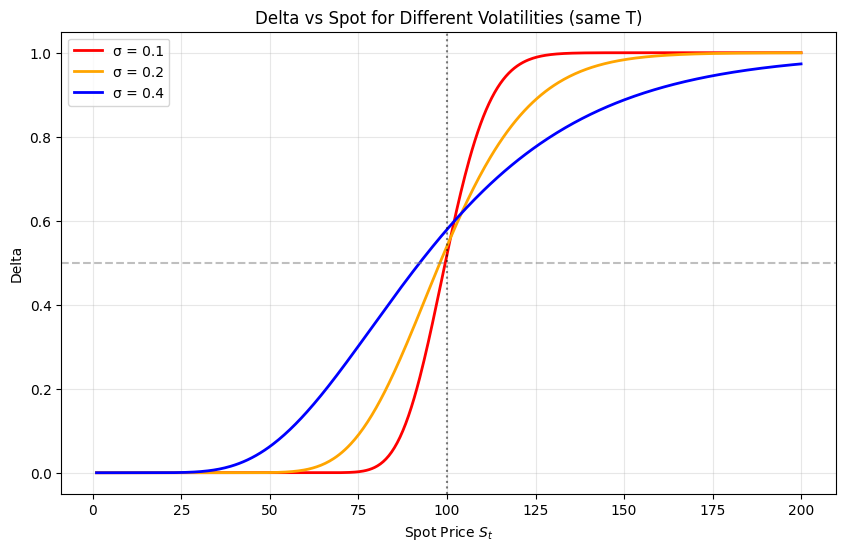

In [4]:
# Volatilities
vols = [0.1, 0.2, 0.4]
colors = ['red', 'orange', 'blue']

S = np.linspace(1, 200, 500)
K = 100
T = 1
r = 0

plt.figure(figsize=(10, 6))

for sigma, color in zip(vols, colors):
    plt.plot(S, delta_call(S, K, T, r, sigma), color=color, linewidth=2, label=f'σ = {sigma}')

plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=K, color='black', linestyle=':', alpha=0.5)
plt.xlabel("Spot Price $S_t$")
plt.ylabel("Delta")
plt.title("Delta vs Spot for Different Volatilities (same T)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---

## Gamma

**Gamma** = the rate of change of Delta with respect to spot price:

$$\Gamma = \frac{\partial \Delta}{\partial S} = \frac{\partial^2 C}{\partial S^2}$$

### Practical interpretation

| Gamma | Interpretation |
|-------|----------------|
| **High Γ** (ATM, short T) | Delta changes rapidly → need to rehedge frequently |
| **Low Γ** (ITM/OTM, long T) | Delta stable → less rebalancing needed |


- **Gamma is highest ATM** → Delta is most sensitive at $S = K$
- **Gamma increases as T → 0** → Delta becomes a step function, gamma becomes a spike
- **Gamma risk** = cost of rehedging; option sellers are "short gamma" (they lose from big moves)

- **Long gamma**: you benefit from large moves (rebalancing profits)
- **Short gamma**: you suffer from large moves (rebalancing costs)

$$\text{P\&L from gamma} \approx \frac{1}{2} \Gamma \cdot (\Delta S)^2$$

### Under Black-Scholes, the gamma is given by:

$$\Gamma_{\text{call}}=\Gamma_{\text{put}} = \frac{\phi(d_1)}{S \cdot \sigma \cdot \sqrt{T}} = \frac{e^{-\frac{d_1^2}{2}}}{S \cdot \sigma \cdot \sqrt{2\pi T}}$$

with $$d_1 = \frac{\ln(S/K) + (r + \frac{\sigma^2}{2})T}{\sigma\sqrt{T}}$$

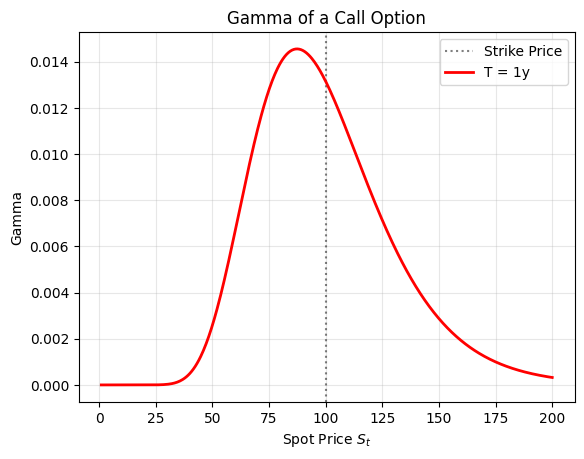

In [5]:
def gamma(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return np.exp(-0.5 * d1**2) / (S * sigma * np.sqrt(2 * np.pi * T))



S = np.linspace(1, 200, 500)  
K=100
T=1
r=0
sigma=0.3

plt.axvline(x=K, color='black', linestyle=':', alpha=0.5, label='Strike Price')
plt.plot(S, gamma(S, K, T, r, sigma), color="red", linewidth=2, label=f'T = {T}y')
plt.xlabel("Spot Price $S_t$")
plt.ylabel("Gamma")
plt.title("Gamma of a Call Option")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

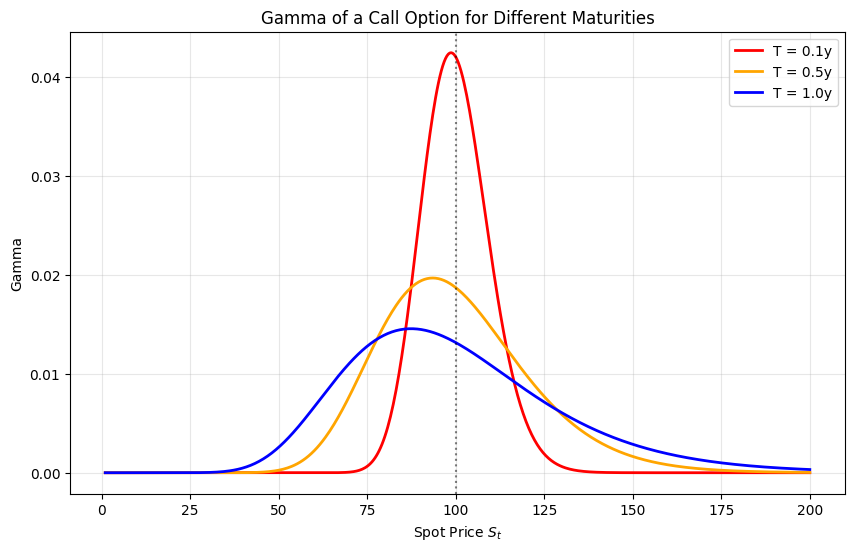

In [6]:
# Maturities
maturities = [0.1, 0.5, 1.0]  # t1 < t2 < t3
colors = ['red', 'orange', 'blue']

plt.figure(figsize=(10, 6))

for T, color in zip(maturities, colors):
    plt.plot(S, gamma(S, K, T, r, sigma), color=color, linewidth=2, label=f'T = {T}y')

plt.axvline(x=K, color='black', linestyle=':', alpha=0.5)
plt.xlabel("Spot Price $S_t$")
plt.ylabel("Gamma")
plt.title("Gamma of a Call Option for Different Maturities")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Gamma Behavior as Maturity Approaches ($T \to 0$)

Whether Gamma increases or decreases depends on the **moneyness** of the option.

#### 1. At-The-Money (ATM) Gamma Spikes
For an option where the spot price is equal to the strike ($S = K$), Gamma **increases** significantly as time to maturity ($T$) decreases. As $T \to 0$, the Delta must transition from 0 to 1 over an infinitely small price change.
$$T_1 < T_2 \implies \Gamma_{T_1}(S=K) > \Gamma_{T_2}(S=K)$$

#### 2. OTM and ITM Gamma Collapses
For options that are Out-of-the-Money or In-the-Money ($S \neq K$), Gamma **decreases** toward zero as maturity approaches. This occurs because the probability of the option changing its exercise status (Delta moving from 0 to 1 or vice versa) becomes negligible as time runs out.

#### 3. Mathematical Limit at Expiry
At the moment of expiration, Gamma exhibits **Dirac-delta** behavior, peaking infinitely at the strike and vanishing everywhere else:

$$\lim_{T \to 0} \Gamma(S) = 
\begin{cases} 
+\infty & \text{if } S = K \\
0 & \text{if } S \neq K
\end{cases}$$

---


**Summary Table: Impact of Passing Time on Gamma**
| Moneyness | Gamma Trend as $T \to 0$ | Reason |
| :--- | :--- | :--- |
| **At-The-Money ($S \approx K$)** | **Spikes (Increases)** | Delta becomes extremely sensitive to small price moves. |
| **In/Out-of-The-Money** | **Collapses (Decreases)** | Delta stabilizes at 0 or 1, making its rate of change (Gamma) zero. |

### Effect of T and σ on Gamma

Both increasing **maturity T** and **volatility σ** have the same effect on gamma:

$$\Gamma \propto \frac{1}{\sigma\sqrt{T}}$$

| Change | Effect on Gamma |
|--------|-----------------|
| ↑ T or ↑ σ | Lower, flatter curve |
| ↓ T or ↓ σ | Higher, sharper peak at ATM |

**Intuition**: More uncertainty spreads sensitivity across a wider range of spot prices.

In [7]:
# Volatilities
vols = [0.1, 0.2, 0.4]  # σ1 < σ2 < σ3
colors = ['red', 'orange', 'blue']

S = np.linspace(1, 200, 500)
K = 100
T = 1
r = 0

plt.figure(figsize=(10, 6))

for sigma, color in zip(vols, colors):
    plt.plot(S, gamma_call(S, K, T, r, sigma), color=color, linewidth=2, label=f'σ = {sigma}')

plt.axvline(x=K, color='black', linestyle=':', alpha=0.5)
plt.xlabel("Spot Price $S_t$")
plt.ylabel("Gamma")
plt.title("Gamma of a Call Option for Different Volatilities")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

NameError: name 'gamma_call' is not defined

<Figure size 1000x600 with 0 Axes>

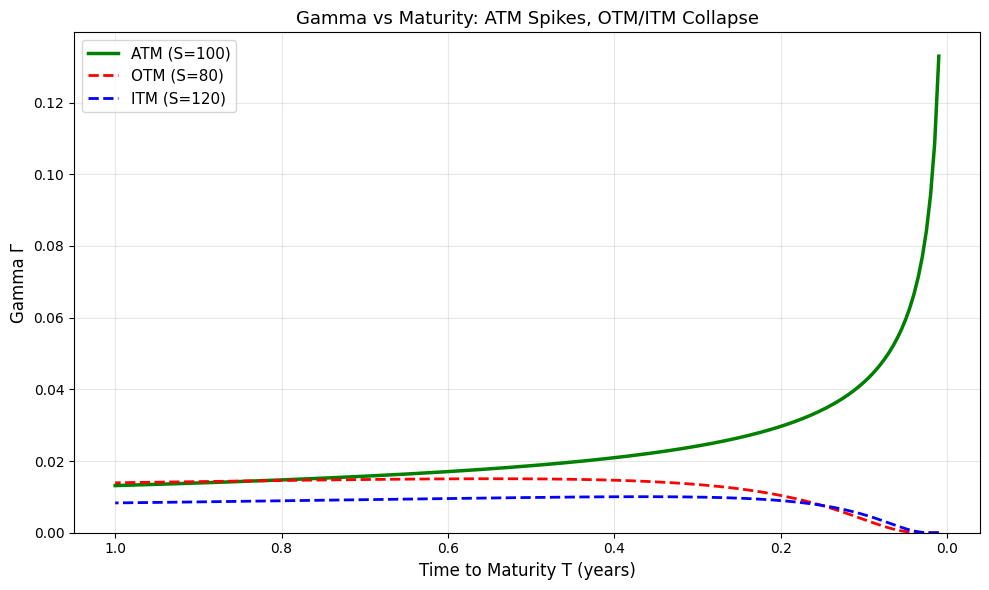

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
def gamma_robust(S, K, r, T, sigma):
    """Robust gamma calculation that handles edge cases"""
    S = np.atleast_1d(np.asarray(S, dtype=float))
    T = np.atleast_1d(np.asarray(T, dtype=float))
    
    # Handle broadcasting
    if S.shape != T.shape:
        if S.size == 1:
            S = np.full_like(T, S[0])
        elif T.size == 1:
            T = np.full_like(S, T[0])
    
    result = np.zeros_like(S)
    
    # Only compute where T > small threshold
    valid = T > 1e-6
    
    if np.any(valid):
        S_v = S[valid]
        T_v = T[valid]
        sqrt_T = np.sqrt(T_v)
        d1 = (np.log(S_v / K) + (r + 0.5 * sigma**2) * T_v) / (sigma * sqrt_T)
        result[valid] = np.exp(-0.5 * d1**2) / (S_v * sigma * sqrt_T * np.sqrt(2 * np.pi))
    
    return result
# Parameters
K = 100
sigma = 0.3
r = 0
T_range = np.linspace(0.01, 1, 200)
# Calculate gamma for different moneyness
gamma_atm = gamma_robust(100, K, r, T_range, sigma)
gamma_otm = gamma_robust(80, K, r, T_range, sigma)
gamma_itm = gamma_robust(120, K, r, T_range, sigma)
# Plot
plt.figure(figsize=(10, 6))
plt.plot(T_range, gamma_atm, 'green', lw=2.5, label='ATM (S=100)')
plt.plot(T_range, gamma_otm, 'red', lw=2, ls='--', label='OTM (S=80)')
plt.plot(T_range, gamma_itm, 'blue', lw=2, ls='--', label='ITM (S=120)')
plt.gca().invert_xaxis()
plt.xlabel("Time to Maturity T (years)", fontsize=12)
plt.ylabel("Gamma Γ", fontsize=12)
plt.title("Gamma vs Maturity: ATM Spikes, OTM/ITM Collapse", fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim(bottom=0)  # Gamma is always positive
plt.tight_layout()
plt.show()

---

# Vega : $\nu$

**Measures the rate of change of the option price with change in the implied volatility of the underlying asset.**

### Formula : $\nu = \frac{\partial \Pi}{\partial \sigma}$  


In BS, for a non-dividend paying stock : $\nu = S N'(d_1) \sqrt{T}$

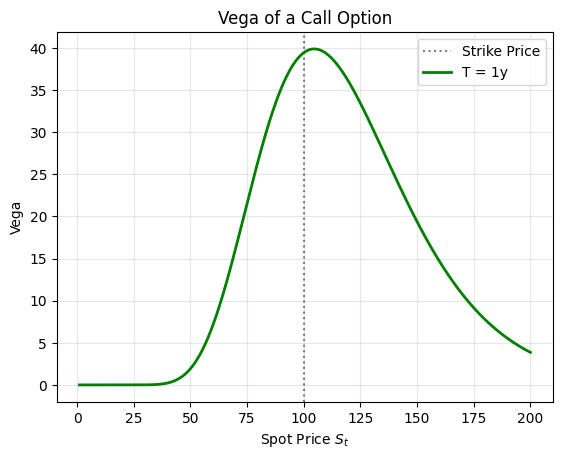

In [ ]:
def vega(S, K, T, r, sigma) :
    d1 = (np.log(S/K) + (r + 0.5*(sigma**2))*T)/ (sigma*np.sqrt(T))
    return S*np.sqrt(T)*np.exp(-0.5*(d1**2))*1/np.sqrt(2*np.pi)

S = np.linspace(1, 200, 500)  
K=100
T=1
r=0
sigma=0.3

plt.axvline(x=K, color='black', linestyle=':', alpha=0.5, label='Strike Price')
plt.plot(S, vega(S, K, T, r, sigma), color="green", linewidth=2, label=f'T = {T}y') 
plt.xlabel("Spot Price $S_t$")
plt.ylabel("Vega")
plt.title("Vega of a Call Option")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### Key Results for Vega with $T_1 < T_2$
##### 1. Vega increases with maturity (at ATM)
$$T_1 < T_2 \implies \nu(T_1) < \nu(T_2)$$
$$\frac{\partial \nu}{\partial T} > 0 \quad \text{(for ATM options)}$$
##### 2. Peak vega scales with $\sqrt{T}$
$$\nu_{\text{ATM}} \approx K \cdot \sqrt{T} \cdot N'(d_1)$$
$$\nu_{\text{max}} \propto \sqrt{T}$$
##### 3. Curve width increases with maturity
$$\text{Vega dispersion} \propto \sigma \sqrt{T}$$
#### Summary
$$\boxed{T_1 < T_2 \implies \nu(S, K, T_1) < \nu(S, K, T_2) \text{ near ATM}}$$

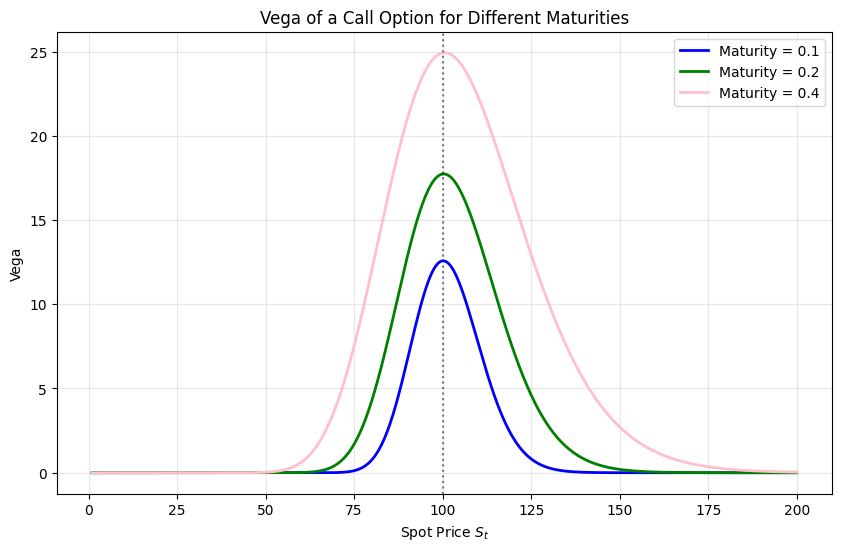

In [ ]:
maturities = [0.1, 0.5, 1, 2]
colors =["blue", "green", "pink", "orange"]

S=np.linspace(1, 200, 500)
K=100
T=1
sigma=0.3
r=0.03

plt.figure(figsize=(10, 6))

for T, color in zip(vols, colors):
    plt.plot(S, vega(S, K, T, r, sigma), color=color, linewidth=2, label=f'Maturity = {T}')

plt.axvline(x=K, color='black', linestyle=':', alpha=0.5)
plt.xlabel("Spot Price $S_t$")
plt.ylabel("Vega")
plt.title("Vega of a Call Option for Different Maturities")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Vega Behavior Relative to Volatility ($\sigma$)

Vega measures the sensitivity of the option price to changes in implied volatility. While Vega is always positive for long positions, its magnitude is heavily influenced by the level of volatility itself.

#### 1. Vega "Flattening" with Increasing Volatility
As volatility ($\sigma$) increases, the Vega curve becomes shorter and wider. High volatility "spreads out" the extrinsic value over a wider range of spot prices, meaning the marginal impact of a 1% change in $\sigma$ is reduced at the peak.
$$\sigma_1 < \sigma_2 \implies \nu_{\text{max}}(\sigma_1) > \nu_{\text{max}}(\sigma_2)$$

#### 2. Peak Vega Sensitivity (Vomma/Volga)
The rate at which Vega changes with respect to volatility is called **Vomma** (or Volga).
* **Near-the-Money:** Vega is generally at its maximum when the option is At-the-Money (ATM).
* **Directional Change:** For ATM options, as $\sigma$ increases, Vega actually **decreases** ($\frac{\partial \nu}{\partial \sigma} < 0$).
* **OTM/ITM:** For options far from the strike, an increase in $\sigma$ can initially **increase** Vega as the option gains extrinsic value.

#### 3. Curve Width and Dispersion
The "width" of the Vega curve (the price range where the option has significant volatility sensitivity) is proportional to the total standard deviation of the price move.
$$\text{Vega dispersion} \propto \sigma \sqrt{T}$$
Increasing volatility increases the dispersion, meaning the option remains sensitive to volatility changes over a broader range of spot prices, even if the absolute peak sensitivity is lower.

---

#### Summary of Vega Dynamics
| Parameter Change | Effect on Peak Vega ($\nu_{\text{max}}$) | Effect on Curve Width |
| :--- | :--- | :--- |
| **Increasing Maturity ($T \uparrow$)** | **Increases** | **Widens** |
| **Increasing Volatility ($\sigma \uparrow$)** | **Decreases** | **Widens** |

$$\boxed{\sigma_1 < \sigma_2 \implies \nu(S \approx K, \sigma_1) > \nu(S \approx K, \sigma_2)}$$

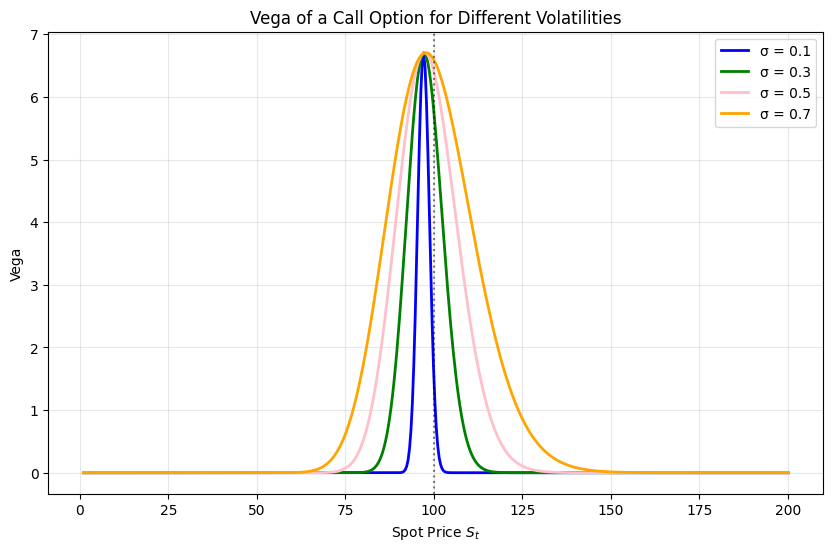

In [ ]:
vols = [0.1, 0.3, 0.5, 0.7]
colors = ["blue", "green", "pink", "orange"]
S = np.linspace(1, 200, 500)
K = 100
T = 1
r = 0.03
plt.figure(figsize=(10, 6))
for sigma, color in zip(vols, colors):
    plt.plot(S, vega(S, K, r, T, sigma), color=color, linewidth=2, label=f'σ = {sigma}')
plt.axvline(x=K, color='black', linestyle=':', alpha=0.5)
plt.xlabel("Spot Price $S_t$")
plt.ylabel("Vega")
plt.title("Vega of a Call Option for Different Volatilities")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Volga (Vomma) Summary

**Definition:** The sensitivity of **Vega** to changes in **Implied Volatility** ($\sigma$). It is the second-order derivative of the option price with respect to volatility.

$$\text{Volga} = \frac{\partial \nu}{\partial \sigma} = \frac{\partial^2 P}{\partial \sigma^2}$$

#### Key Characteristics
* **Convexity:** Measures how much "Long Vega" you gain or lose as volatility moves.
* **ATM Behavior:** Volga is typically **negative or near zero** at-the-money, as high volatility "flattens" the Vega peak.
* **OTM/ITM Behavior:** Volga is **positive** for options away from the strike, meaning their sensitivity to volatility increases as the market becomes more volatile.
* **Market Impact:** High Volga indicates a position that benefits from "vol-of-vol"—large swings in implied volatility itself.

| Position | Volga Sign | Impact of Volatility Rise ($\sigma \uparrow$) |
| :--- | :--- | :--- |
| **At-The-Money** | **Negative/Zero** | Vega peak lowers; marginal impact of $\sigma$ decreases. |
| **OTM / ITM** | **Positive** | Option becomes significantly more sensitive to volatility. |

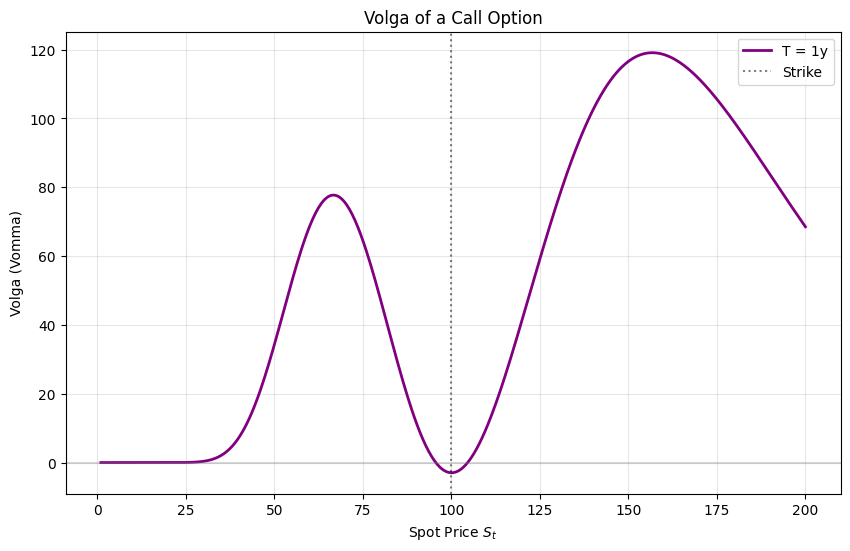

In [ ]:
def volga(S, K, r, T, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    vega_val = S * np.sqrt(T) * np.exp(-0.5*d1**2) / np.sqrt(2*np.pi)
    return vega_val * d1 * d2 / sigma
S = np.linspace(1, 200, 500)
K = 100
T = 1
r = 0
sigma = 0.3
plt.figure(figsize=(10, 6))
plt.plot(S, volga(S, K, r, T, sigma), color="purple", linewidth=2, label=f'T = {T}y')
plt.axvline(x=K, color='black', linestyle=':', alpha=0.5, label='Strike')
plt.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
plt.xlabel("Spot Price $S_t$")
plt.ylabel("Volga (Vomma)")
plt.title("Volga of a Call Option")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()